# 따릉이 자치구별 수요예측 - 지역구 · 날씨별 이용량 분석 (코로나 시기 제외)

**목표**
1. 자치구마다 날씨(기온 · 강수량 · 미세먼지)에 따라 이용량이 어떻게 달라지는지 분석
2. **"자치구 + 날짜 + 시간"을 넣으면 그 시간의 대여량을 예측**하는 모델용 데이터 만들기

| 구분 | 내용 |
|---|---|
| 입력 X | 자치구, 시간, 요일, 기온, 강수량, 휴일 여부, 과거 대여량 ... |
| 정답 y | 그 자치구 · 그 시간의 따릉이 대여량 |

**폴더 구조**
```
data
├─ usage   따릉이 대여반납이력  (usage\20\2001_merge.csv, usage\21\2101_merge.csv ...)
├─ temp    기온      (일일기온_2020.csv ...)
├─ rain    강수량    (일일강수량_2020.csv ...)
└─ air     대기오염  (일별평균대기오염도_2020.csv ...)
```
날씨 폴더의 월별 · 연별 파일은 사용하지 않습니다. (일일 데이터로 직접 계산 가능)

**코로나 시기(2020~2021)는 제외**하고 분석합니다. (시각화 · train/valid/test 모두 `START_YEAR`(2022)부터)
단, 모델 노트북에서 "코로나 포함 vs 제외" 비교를 하려고 **읽기는 2020년부터** 하고,
2020~2021년 모델 데이터는 `train_covid.csv`로 **따로** 저장합니다. (train.csv 에는 섞이지 않음)

**저장 파일** (`model_data_2022` 폴더)
| 파일 | 내용 |
|---|---|
| train / valid / test.csv | 자치구 × 시간 모델 데이터 (코로나 제외) |
| train_covid.csv | 2020~2021 모델 데이터 (비교용) |
| features.txt | 입력 X 변수 목록 |
| holidays.txt | 공휴일 목록 (미래 예측용) |
| 대여소_월별시간별.csv | 최근 2년 대여소별 · 시간별 대여량 (웹에서 대여소별 예측용) |

**순서**: 0) 설정 · 공휴일 → 1) 파일 확인 → 2) 따릉이 → 3) 날씨 → 4) 합치기 → 5) 시각화 → 6) 시간 단위 모델 데이터 만들기 → 7) 저장

In [1]:
import glob
import re
import os
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager

warnings.filterwarnings("ignore")

# ---------- 공통 함수 (이 셀에 같이 두어 빠뜨리지 않게) ----------

# 인코딩이 달라도(utf-8 / cp949) 읽는 함수
def read_csv_any(path, **kwargs):
    for enc in ["utf-8-sig", "cp949"]:
        try:
            return pd.read_csv(path, encoding=enc, **kwargs)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"인코딩을 알 수 없는 파일: {path}")


# 컬럼 이름 비교용: 띄어쓰기와 보이지 않는 문자 제거
def clean_name(c):
    return str(c).replace("\ufeff", "").replace(" ", "").strip()


# 날짜+시간 변환 (형식이 섞여 있어도 최대한 읽기)
def to_datetime_safe(s):
    out = pd.to_datetime(s, errors="coerce")
    if out.isna().mean() > 0.01:
        try:
            out = pd.to_datetime(s, errors="coerce", format="mixed")  # pandas 2.0 이상
        except (TypeError, ValueError):
            pass
    return out


# 날짜만 변환 (2020-01-01, 20200101, 2020.01.01 모두 가능)
def to_date_safe(s):
    text = s.astype(str).str.replace(r"\.0$", "", regex=True)
    digits = text.str.replace(r"\D", "", regex=True).str[:8]
    out = pd.to_datetime(digits, format="%Y%m%d", errors="coerce")
    return out.fillna(pd.to_datetime(text, errors="coerce"))

## 0. 설정
데이터 위치가 바뀌면 `DATA_DIR` 한 줄만 고치면 됩니다.

In [2]:
DATA_DIR = r"c:\Users\Admin\Desktop\project\데이터분석\data"

# ** 는 "하위 폴더 전부"라는 뜻 → usage\20, usage\21 ... 안의 파일을 모두 찾음
BIKE_FILES = os.path.join(DATA_DIR, "usage", "**", "*_merge.csv")
TEMP_FILES = os.path.join(DATA_DIR, "temp", "**", "일일기온_*.csv")
RAIN_FILES = os.path.join(DATA_DIR, "rain", "**", "일일강수량_*.csv")
AIR_FILES = os.path.join(DATA_DIR, "air", "**", "일별평균대기오염도_*.csv")

# 분석 · 학습 시작 연도 (코로나 시기 2020~2021 제외)
START_YEAR = 2022

# 코로나 포함 vs 제외 비교용으로 읽기는 2020년부터 (2020~2021은 train_covid.csv 로 따로 저장)
READ_START_YEAR = 2020

# 대여소별 데이터는 최근 몇 년치만 저장 (웹에서 대여소별 예측할 때 사용)
STATION_YEARS = 2

# 따릉이 원본을 줄인 결과를 저장해두고 다음부터 재사용 (파일 목록이 바뀌면 자동으로 다시 만듦)
CACHE_FILE = f"./cache_따릉이_시간별집계_{READ_START_YEAR}.csv"
STATION_CACHE_FILE = f"./cache_따릉이_대여소별집계_{READ_START_YEAR}.csv"

# 모델용 데이터 저장 폴더 (전체 기간 데이터와 섞이지 않게 따로 저장)
OUT_DIR = f"./model_data_{START_YEAR}"

In [3]:
# 한글 폰트 설정
def set_korean_font():
    if platform.system() == "Windows":
        font = "Malgun Gothic"
    elif platform.system() == "Darwin":
        font = "AppleGothic"
    else:
        names = [f.name for f in font_manager.fontManager.ttflist]
        font = next((n for n in names if "Nanum" in n or "CJK" in n or n == "Noto Sans KR"), None)
    if font:
        plt.rcParams["font.family"] = font
    plt.rcParams["axes.unicode_minus"] = False

sns.set_style("whitegrid")
set_korean_font()

### 공휴일 · 계절
따릉이 집계(2번)에서 쉬는날을 계산할 때도 쓰기 때문에 앞쪽에 둡니다.

In [4]:
# 공휴일 (선거일 · 임시공휴일 · 대체공휴일 포함) ※ 한 번 확인해주세요
HOLIDAYS = pd.to_datetime([
    "2020-01-01", "2020-01-24", "2020-01-25", "2020-01-26", "2020-01-27", "2020-03-01",
    "2020-04-15", "2020-04-30", "2020-05-05", "2020-06-06", "2020-08-15", "2020-08-17",
    "2020-09-30", "2020-10-01", "2020-10-02", "2020-10-03", "2020-10-09", "2020-12-25",
    "2021-01-01", "2021-02-11", "2021-02-12", "2021-02-13", "2021-03-01", "2021-05-05",
    "2021-05-19", "2021-06-06", "2021-08-15", "2021-08-16", "2021-09-20", "2021-09-21",
    "2021-09-22", "2021-10-03", "2021-10-04", "2021-10-09", "2021-10-11", "2021-12-25",
    "2022-01-01", "2022-01-31", "2022-02-01", "2022-02-02", "2022-03-01", "2022-03-09",
    "2022-05-05", "2022-05-08", "2022-06-01", "2022-06-06", "2022-08-15", "2022-09-09",
    "2022-09-10", "2022-09-11", "2022-09-12", "2022-10-03", "2022-10-09", "2022-10-10",
    "2022-12-25",
    "2023-01-01", "2023-01-21", "2023-01-22", "2023-01-23", "2023-01-24", "2023-03-01",
    "2023-05-05", "2023-05-27", "2023-05-29", "2023-06-06", "2023-08-15", "2023-09-28",
    "2023-09-29", "2023-09-30", "2023-10-02", "2023-10-03", "2023-10-09", "2023-12-25",
    "2024-01-01", "2024-02-09", "2024-02-10", "2024-02-11", "2024-02-12", "2024-03-01",
    "2024-04-10", "2024-05-05", "2024-05-06", "2024-05-15", "2024-06-06", "2024-08-15",
    "2024-09-16", "2024-09-17", "2024-09-18", "2024-10-01", "2024-10-03", "2024-10-09",
    "2024-12-25",
    "2025-01-01", "2025-01-27", "2025-01-28", "2025-01-29", "2025-01-30", "2025-03-01",
    "2025-03-03", "2025-05-05", "2025-05-06", "2025-06-03", "2025-06-06", "2025-08-15",
    "2025-10-03", "2025-10-05", "2025-10-06", "2025-10-07", "2025-10-08", "2025-10-09",
    "2025-12-25",
    # 2026년 (미래 예측용) ※ 확정 여부 한 번 확인해주세요
    "2026-01-01", "2026-02-16", "2026-02-17", "2026-02-18", "2026-03-01", "2026-03-02",
    "2026-05-05", "2026-05-24", "2026-05-25", "2026-06-03", "2026-06-06", "2026-08-15",
    "2026-08-17", "2026-09-24", "2026-09-25", "2026-09-26", "2026-10-03", "2026-10-05",
    "2026-10-09", "2026-12-25",
])
SEASON = {3: "봄", 4: "봄", 5: "봄", 6: "여름", 7: "여름", 8: "여름",
          9: "가을", 10: "가을", 11: "가을", 12: "겨울", 1: "겨울", 2: "겨울"}

## 1. 파일 확인
여기서 개수가 이상하면 다음으로 넘어가지 말고 경로부터 확인하세요.

In [5]:
# 파일 이름에서 연도 찾기 (2201_merge.csv → 2022, 일일기온_2022.csv → 2022)
def file_year(path):
    name = os.path.basename(path)
    m = re.match(r"(\d{2})\d{2}_merge", name)
    if m:
        return 2000 + int(m.group(1))
    m = re.search(r"(20\d{2})", name)
    if m:
        return int(m.group(1))
    return None   # 연도를 모르면 일단 읽고, 아래에서 날짜로 거름


# READ_START_YEAR 이후 파일만 찾기
def find_files(pattern):
    files = sorted(glob.glob(pattern, recursive=True))
    return [f for f in files if file_year(f) is None or file_year(f) >= READ_START_YEAR]

print(f"{READ_START_YEAR}년 이후 파일을 읽습니다. (분석 · 학습은 {START_YEAR}년부터)\n")

file_lists = {
    "따릉이": find_files(BIKE_FILES),
    "기온": find_files(TEMP_FILES),
    "강수량": find_files(RAIN_FILES),
    "대기오염": find_files(AIR_FILES),
}

for name, files in file_lists.items():
    print(f"[{name}] {len(files)}개")
    for f in files[:3]:
        print("   ", os.path.relpath(f, DATA_DIR))
    if len(files) > 3:
        print("    ...")

empty = [name for name, files in file_lists.items() if len(files) == 0]
if empty:
    raise FileNotFoundError(f"파일을 찾지 못함: {empty} → DATA_DIR와 파일 이름을 확인하세요.")

2020년 이후 파일을 읽습니다. (분석 · 학습은 2022년부터)

[따릉이] 72개
    usage\20\2001_merge.csv
    usage\20\2002_merge.csv
    usage\20\2003_merge.csv
    ...
[기온] 6개
    temp\일일기온_2020.csv
    temp\일일기온_2021.csv
    temp\일일기온_2022.csv
    ...
[강수량] 6개
    rain\일일강수량_2020.csv
    rain\일일강수량_2021.csv
    rain\일일강수량_2022.csv
    ...
[대기오염] 6개
    air\일별평균대기오염도_2020.csv
    air\일별평균대기오염도_2021.csv
    air\일별평균대기오염도_2022.csv
    ...


## 2. 따릉이 데이터

원본이 커서 **파일 하나씩 읽고 → "시간 × 자치구별 건수"로 줄인 뒤 → 합칩니다.**
최근 `STATION_YEARS`년 파일은 **"월 × 대여소 × 쉬는날 × 시간별 건수"** 도 같이 만듭니다. (웹 대여소별 예측용)
대여소번호가 없어서 **자치구 + 대여소명**으로 대여소를 구분합니다.
처음 한 번은 오래 걸리고(파일 수에 따라 수십 분), 이후에는 저장된 집계 파일을 바로 읽습니다.

In [7]:
def summarize_bike_file(path, with_station=False):
    wanted = {"대여일시": "대여일시", "대여자치구": "대여자치구", "반납자치구": "반납자치구"}
    if with_station:
        wanted["대여대여소명"] = "대여소명"
    df = read_csv_any(path, usecols=lambda c: clean_name(c) in wanted)
    df = df.rename(columns=lambda c: wanted[clean_name(c)])

    missing = [c for c in wanted.values() if c not in df.columns]
    if missing:
        real_cols = read_csv_any(path, nrows=0).columns.tolist()
        print(f"  [건너뜀] {os.path.basename(path)} - 없는 컬럼 {missing} / 실제 컬럼 {real_cols}")
        return None, None

    df["일시"] = to_datetime_safe(df["대여일시"]).dt.floor("60min")
    bad = df["일시"].isna().sum()
    if bad > 0:
        print(f"  {os.path.basename(path)}: 날짜를 읽지 못한 {bad}행 제외")
    df = df.dropna(subset=["일시", "대여자치구"])

    # (1) 자치구 × 시간
    df["다른구반납"] = (df["대여자치구"] != df["반납자치구"]).astype(int)
    gu_part = (
        df.groupby(["일시", "대여자치구"])
        .agg(대여량=("다른구반납", "size"), 다른구반납=("다른구반납", "sum"))
        .reset_index()
    )

    # (2) 월 × 대여소 × 쉬는날 × 시간 (최근 파일만)
    st_part = None
    if with_station:
        day = df["일시"].dt.normalize()
        df["연월"] = day.dt.strftime("%Y-%m")
        df["쉬는날"] = ((day.dt.dayofweek >= 5) | day.isin(HOLIDAYS)).astype(int)
        df["시간"] = df["일시"].dt.hour
        df["대여소명"] = df["대여소명"].astype(str).str.strip()
        st_part = (
            df.groupby(["연월", "대여자치구", "대여소명", "쉬는날", "시간"])
            .size().rename("대여량").reset_index()
        )
    return gu_part, st_part


bike_files = file_lists["따릉이"]
years_in_files = [file_year(f) for f in bike_files if file_year(f) is not None]
station_from = max(years_in_files) - STATION_YEARS + 1   # 이 연도부터 대여소 데이터도 만듦

signature_file = CACHE_FILE + ".files.txt"
signature = f"STATION_YEARS={STATION_YEARS}\n" + "\n".join(os.path.basename(f) for f in bike_files)
old_signature = open(signature_file, encoding="utf-8").read() if os.path.exists(signature_file) else ""

if os.path.exists(CACHE_FILE) and os.path.exists(STATION_CACHE_FILE) and signature == old_signature:
    hourly = pd.read_csv(CACHE_FILE, parse_dates=["일시"])
    station = pd.read_csv(STATION_CACHE_FILE, encoding="utf-8-sig")
    print("저장된 집계 파일을 불러왔습니다.")
else:
    print(f"따릉이 파일 {len(bike_files)}개 집계 시작 (대여소 데이터: {station_from}년부터)")
    parts, st_parts = [], []
    for i, f in enumerate(bike_files, 1):
        y = file_year(f)
        part, st_part = summarize_bike_file(f, with_station=(y is None or y >= station_from))
        if part is not None:
            parts.append(part)
        if st_part is not None:
            st_parts.append(st_part)
        print(f"  {i}/{len(bike_files)} {os.path.basename(f)}")
    if len(parts) == 0:
        raise ValueError("읽은 파일이 없습니다. 위의 '[건너뜀]' 메시지를 확인하세요.")

    hourly = pd.concat(parts, ignore_index=True)
    hourly = hourly.groupby(["일시", "대여자치구"], as_index=False)[["대여량", "다른구반납"]].sum()
    hourly.to_csv(CACHE_FILE, index=False, encoding="utf-8-sig")

    station = pd.concat(st_parts, ignore_index=True)
    station = station.groupby(["연월", "대여자치구", "대여소명", "쉬는날", "시간"], as_index=False)["대여량"].sum()
    station.to_csv(STATION_CACHE_FILE, index=False, encoding="utf-8-sig")

    with open(signature_file, "w", encoding="utf-8") as fp:
        fp.write(signature)
    print("집계 파일 저장:", CACHE_FILE, "/", STATION_CACHE_FILE)

hourly = hourly.rename(columns={"대여자치구": "자치구"})
hourly = hourly[hourly["일시"].dt.year >= READ_START_YEAR].reset_index(drop=True)   # 한 번 더 확인
station = station.rename(columns={"대여자치구": "자치구"})
print(hourly.shape)
print("기간:", hourly["일시"].min(), "~", hourly["일시"].max())
print("대여소 데이터:", station["연월"].min(), "~", station["연월"].max(),
      f"/ 대여소 {station.groupby(['자치구', '대여소명']).ngroups}곳")
hourly.head()

따릉이 파일 72개 집계 시작 (대여소 데이터: 2024년부터)
  1/72 2001_merge.csv
  2/72 2002_merge.csv
  3/72 2003_merge.csv
  4/72 2004_merge.csv
  5/72 2005_merge.csv
  6/72 2006_merge.csv
  7/72 2007_merge.csv
  8/72 2008_merge.csv
  9/72 2009_merge.csv
  10/72 2010_merge.csv
  11/72 2011_merge.csv
  12/72 2012_merge.csv
  13/72 2101_merge.csv
  14/72 2102_merge.csv
  15/72 2103_merge.csv
  16/72 2104_merge.csv
  17/72 2105_merge.csv
  18/72 2106_merge.csv
  19/72 2107_merge.csv
  20/72 2108_merge.csv
  21/72 2109_merge.csv
  22/72 2110_merge.csv
  23/72 2111_merge.csv
  24/72 2112_merge.csv
  25/72 2201_merge.csv
  26/72 2202_merge.csv
  27/72 2203_merge.csv
  28/72 2204_merge.csv
  29/72 2205_merge.csv
  30/72 2206_merge.csv
  31/72 2207_merge.csv
  32/72 2208_merge.csv
  33/72 2209_merge.csv
  34/72 2210_merge.csv
  35/72 2211_merge.csv
  36/72 2212_merge.csv
  37/72 2301_merge.csv
  38/72 2302_merge.csv
  39/72 2303_merge.csv
  40/72 2304_merge.csv
  41/72 2305_merge.csv
  42/72 2306_merge.csv
  43/72

,일시,자치구,대여량,다른구반납
0,2020-01-01,강남구,12,3
1,2020-01-01,강동구,14,2
2,2020-01-01,강북구,7,4
3,2020-01-01,강서구,5,0
4,2020-01-01,관악구,16,3


## 3. 날씨 데이터
연도별 파일을 이어 붙이고 컬럼 이름을 통일합니다.

In [8]:
def load_weather(files):
    df = pd.concat([read_csv_any(f) for f in files], ignore_index=True)
    df.columns = [clean_name(c) for c in df.columns]

    # 날짜 / 자치구 컬럼 찾기
    date_col = next(c for c in df.columns if c in ["날짜", "측정일시", "일시", "일자"])
    gu_col = next(c for c in df.columns if c in ["자치구", "측정소명", "구"])
    df = df.rename(columns={date_col: "날짜", gu_col: "자치구"})
    df["날짜"] = to_date_safe(df["날짜"])

    # 값 컬럼 이름 짧게 (단위 제거)
    new_names = {}
    for c in df.columns:
        if "초미세" in c:
            new_names[c] = "초미세먼지"
        elif "미세먼지" in c:
            new_names[c] = "미세먼지"
        elif "평균기온" in c:
            new_names[c] = "평균기온"
        elif "최저기온" in c:
            new_names[c] = "최저기온"
        elif "최고기온" in c:
            new_names[c] = "최고기온"
        elif "강수량" in c:
            new_names[c] = "강수량"
    df = df.rename(columns=new_names)
    value_cols = list(new_names.values())
    df[value_cols] = df[value_cols].apply(pd.to_numeric, errors="coerce")

    df = df[["날짜", "자치구"] + value_cols].dropna(subset=["날짜"])
    return df.drop_duplicates(["날짜", "자치구"])


temp = load_weather(file_lists["기온"])
rain = load_weather(file_lists["강수량"])
air = load_weather(file_lists["대기오염"])

for name, w in [("기온", temp), ("강수량", rain), ("대기오염", air)]:
    print(f"{name}: {len(w)}행, {w['날짜'].min().date()} ~ {w['날짜'].max().date()}, 컬럼 {list(w.columns[2:])}")

weather = temp.merge(rain, on=["날짜", "자치구"], how="outer").merge(air, on=["날짜", "자치구"], how="outer")

# 서울 25개 자치구만 (대기오염에 도로변 측정소 등이 섞여 있을 수 있음)
seoul_gu = sorted(temp["자치구"].unique())
weather = weather[weather["자치구"].isin(seoul_gu)]
weather = weather[weather["날짜"].dt.year >= READ_START_YEAR]
print("자치구 수:", len(seoul_gu))

# 날씨 기간이 따릉이 기간을 덮는지 확인 (2020~2021 날씨 파일이 없으면 코로나 비교가 틀어짐)
w_years = set(weather["날짜"].dt.year)
b_years = set(hourly["일시"].dt.year)
if b_years - w_years:
    print("⚠️ 날씨 파일이 없는 연도:", sorted(b_years - w_years), "→ temp / rain / air 폴더를 확인하세요.")

기온: 54650행, 2020-01-01 ~ 2025-12-31, 컬럼 ['평균기온', '최저기온', '최고기온']
강수량: 54650행, 2020-01-01 ~ 2025-12-31, 컬럼 ['강수량']
대기오염: 54800행, 2020-01-01 ~ 2025-12-31, 컬럼 ['미세먼지', '초미세먼지']
자치구 수: 25


## 4. 일별 데이터로 합치기 + 변수 만들기

In [9]:
hourly["날짜"] = hourly["일시"].dt.normalize()
daily = hourly.groupby(["날짜", "자치구"], as_index=False)[["대여량", "다른구반납"]].sum()
daily = daily[daily["자치구"].isin(seoul_gu)]

# 모든 날짜 × 25개 구 조합 만들기 (기록 없는 날 = 0건)
all_days = pd.date_range(daily["날짜"].min(), daily["날짜"].max(), freq="D")
grid = pd.MultiIndex.from_product([all_days, seoul_gu], names=["날짜", "자치구"]).to_frame(index=False)
daily = grid.merge(daily, on=["날짜", "자치구"], how="left")
print("이용 기록이 없는 (날짜, 구):", daily["대여량"].isna().sum())
daily[["대여량", "다른구반납"]] = daily[["대여량", "다른구반납"]].fillna(0)

df = daily.merge(weather, on=["날짜", "자치구"], how="left")
df = df.sort_values(["자치구", "날짜"]).reset_index(drop=True)

# 날씨 결측치: 강수량은 0, 나머지는 같은 구의 앞뒤 날짜로 채움
weather_cols = ["평균기온", "최저기온", "최고기온", "강수량", "미세먼지", "초미세먼지"]
print("날씨 결측치:", df[weather_cols].isna().sum().to_dict())
df["강수량"] = df["강수량"].fillna(0)
fill_cols = ["평균기온", "최저기온", "최고기온", "미세먼지", "초미세먼지"]
df[fill_cols] = df.groupby("자치구")[fill_cols].transform(lambda s: s.interpolate().bfill().ffill())
print("채운 뒤 결측치:", df[weather_cols].isna().sum().sum())
print(df.shape)

이용 기록이 없는 (날짜, 구): 0
날씨 결측치: {'평균기온': 473, '최저기온': 460, '최고기온': 459, '강수량': 195, '미세먼지': 273, '초미세먼지': 248}
채운 뒤 결측치: 0
(54800, 10)


In [10]:
# 날짜 변수
df["연도"] = df["날짜"].dt.year
df["월"] = df["날짜"].dt.month
df["요일"] = df["날짜"].dt.dayofweek          # 0=월 ~ 6=일
df["주말"] = (df["요일"] >= 5).astype(int)
df["공휴일"] = df["날짜"].isin(HOLIDAYS).astype(int)
df["쉬는날"] = ((df["주말"] == 1) | (df["공휴일"] == 1)).astype(int)
df["계절"] = df["월"].map(SEASON)

# 날씨 변수
df["일교차"] = df["최고기온"] - df["최저기온"]
df["비"] = (df["강수량"] > 0).astype(int)
df["전날강수량"] = df.groupby("자치구")["강수량"].shift(1).fillna(0)

# 과거 이용량 변수 (예측하는 날 기준으로 이미 알고 있는 값만)
g = df.groupby("자치구")["대여량"]
df["전날대여량"] = g.shift(1)
df["지난주같은요일"] = g.shift(7)
df["최근7일평균"] = g.transform(lambda s: s.shift(1).rolling(7).mean())

# 이용비율 = 그 구 · 그 해 평균 대비 몇 배인지
# (구마다 규모가 다르고 해마다 이용량이 늘어나서, 날씨 효과만 보려고 사용)
df["이용비율"] = df["대여량"] / df.groupby(["자치구", "연도"])["대여량"].transform("mean")

# 구간 변수 (시각화용)
df["기온구간"] = pd.cut(df["평균기온"], bins=range(-21, 37, 3))
df["강수구간"] = pd.cut(df["강수량"], bins=[-1, 0, 5, 20, 50, 1000],
                       labels=["없음", "~5mm", "5~20mm", "20~50mm", "50mm~"])
df["미세먼지등급"] = pd.cut(df["미세먼지"], bins=[-1, 30, 80, 150, 9999],
                         labels=["좋음", "보통", "나쁨", "매우나쁨"])
df.head()

,날짜,자치구,대여량,다른구반납,평균기온,최저기온,최고기온,강수량,미세먼지,초미세먼지,...,일교차,비,전날강수량,전날대여량,지난주같은요일,최근7일평균,이용비율,기온구간,강수구간,미세먼지등급
0,2020-01-01,강남구,232,75,-1.7,-5.1,1.0,0.0,31.0,23.0,...,6.1,0,0.0,NaN,NaN,NaN,0.247275,"(-3, 0]",없음,보통
1,2020-01-02,강남구,482,151,2.3,-0.2,5.1,0.0,57.0,43.0,...,5.3,0,0.0,232.0,NaN,NaN,0.513735,"(0, 3]",없음,보통
2,2020-01-03,강남구,530,160,0.9,-2.7,6.0,0.0,61.0,45.0,...,8.7,0,0.0,482.0,NaN,NaN,0.564895,"(0, 3]",없음,보통
3,2020-01-04,강남구,417,117,2.1,-3.6,8.3,0.0,53.0,39.0,...,11.9,0,0.0,530.0,NaN,NaN,0.444455,"(0, 3]",없음,보통
4,2020-01-05,강남구,373,138,1.1,-4.2,7.3,0.0,45.0,34.0,...,11.5,0,0.0,417.0,NaN,NaN,0.397558,"(0, 3]",없음,보통


### 모델용(전체 기간) / 분석용(코로나 제외) 나누기
- `df_all`, `hourly_all`: 2020년부터 전체 → 6번 모델 데이터 만들 때 사용
- `df`, `hourly`: `START_YEAR`(2022)부터 → 5번 시각화에 사용 (기존과 같음)

In [11]:
df_all = df.copy()
hourly_all = hourly.copy()

df = df[df["연도"] >= START_YEAR].reset_index(drop=True)
hourly = hourly[hourly["일시"].dt.year >= START_YEAR].reset_index(drop=True)

print("모델용 기간:", df_all["날짜"].min().date(), "~", df_all["날짜"].max().date())
print("분석용 기간:", df["날짜"].min().date(), "~", df["날짜"].max().date())

모델용 기간: 2020-01-01 ~ 2025-12-31
분석용 기간: 2022-01-01 ~ 2025-12-31


## 5. 시각화
### 5-1. 연도별 · 월별 이용량

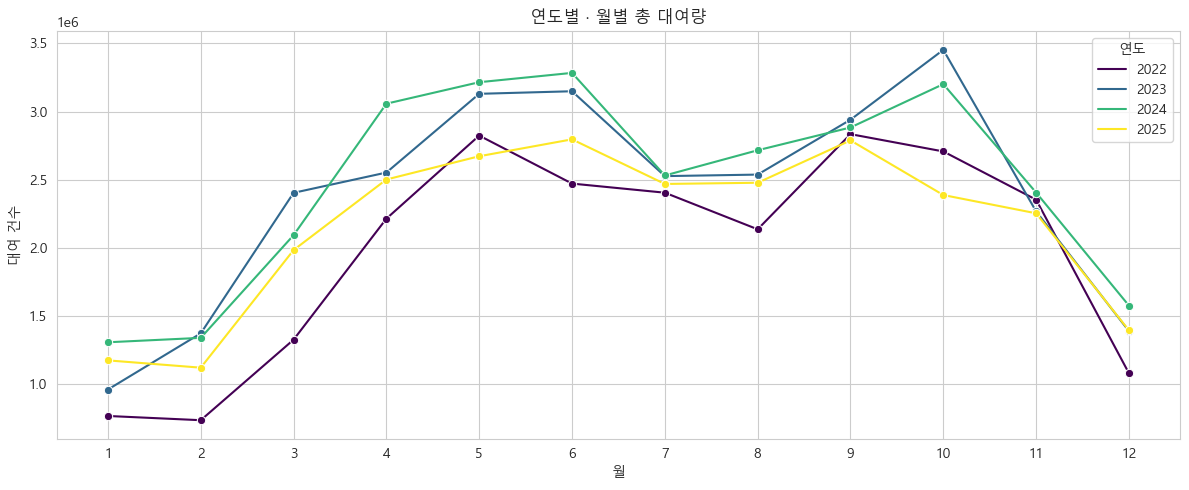

In [12]:
monthly = df.groupby(["연도", "월"], as_index=False)["대여량"].sum()

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly, x="월", y="대여량", hue="연도", marker="o", palette="viridis")
plt.xticks(range(1, 13))
plt.title("연도별 · 월별 총 대여량")
plt.ylabel("대여 건수")
plt.tight_layout()
plt.show()

### 5-2. 자치구 × 연도 이용량

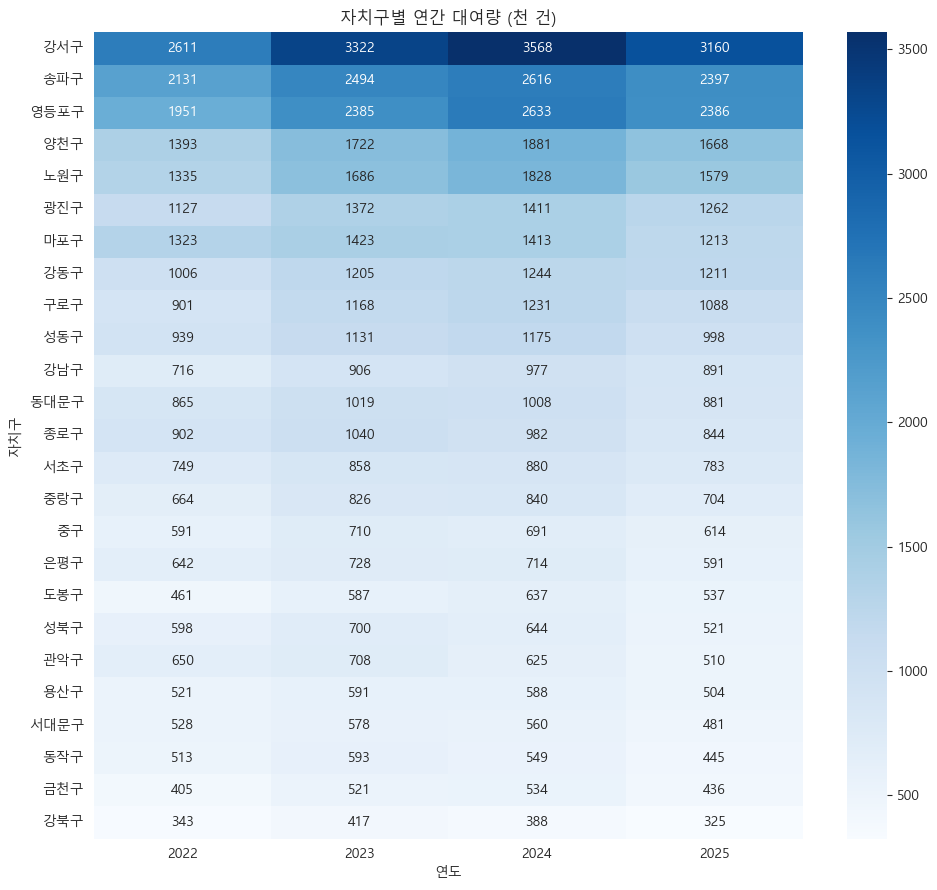

In [13]:
gu_year = df.pivot_table(index="자치구", columns="연도", values="대여량", aggfunc="sum") / 1000
gu_year = gu_year.sort_values(gu_year.columns[-1], ascending=False)

plt.figure(figsize=(10, 9))
sns.heatmap(gu_year, annot=True, fmt=".0f", cmap="Blues")
plt.title("자치구별 연간 대여량 (천 건)")
plt.tight_layout()
plt.show()

### 5-3. 월평균 기온과 이용량

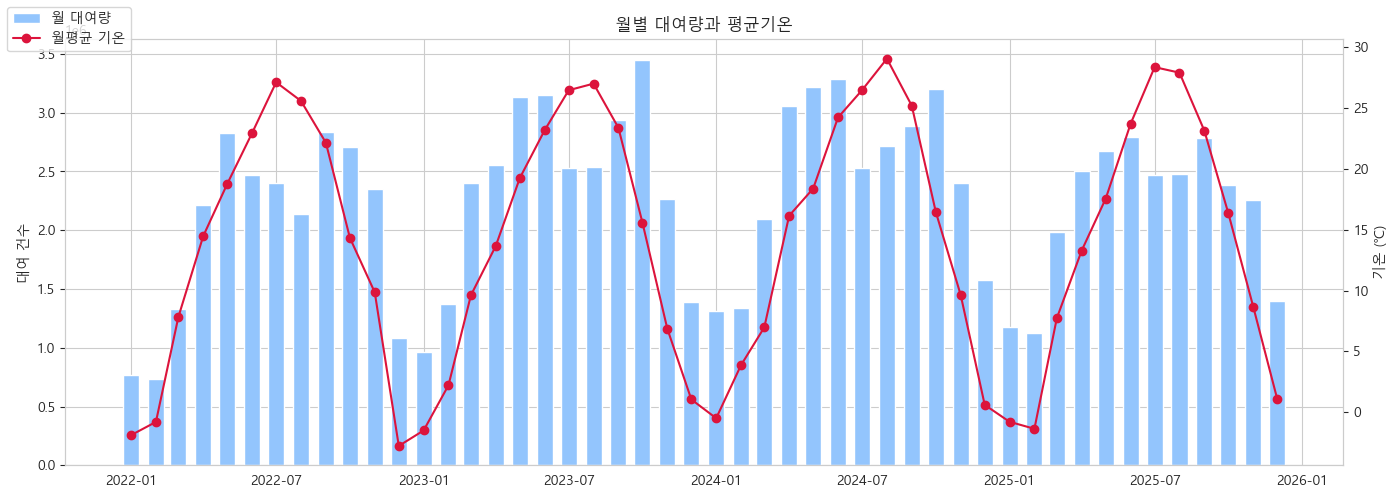

In [14]:
m = df.groupby(pd.Grouper(key="날짜", freq="MS")).agg(대여량=("대여량", "sum"), 평균기온=("평균기온", "mean"))

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.bar(m.index, m["대여량"], width=20, color="#93c5fd", label="월 대여량")
ax1.set_ylabel("대여 건수")
ax2 = ax1.twinx()
ax2.plot(m.index, m["평균기온"], color="crimson", marker="o", label="월평균 기온")
ax2.set_ylabel("기온 (℃)")
ax2.grid(False)
fig.legend(loc="upper left")
plt.title("월별 대여량과 평균기온")
plt.tight_layout()
plt.show()

### 5-4. 날씨 구간별 이용비율 (서울 전체)
1.0 = 평소 수준 / 1.2 = 평소보다 20% 많음 / 0.5 = 평소의 절반

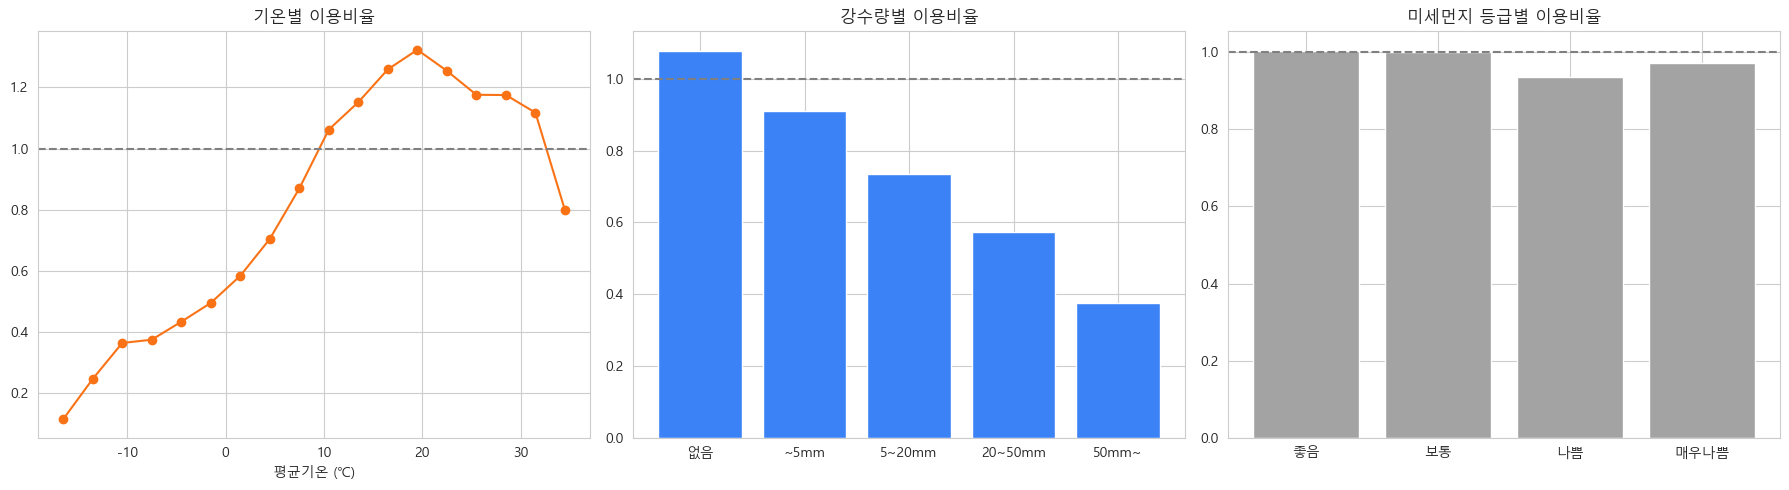

구간별 일수 (구 하나 기준, 너무 적으면 해석 주의)
{'없음': 1093, '~5mm': 181, '5~20mm': 99, '20~50mm': 59, '50mm~': 27}
{'좋음': 794, '보통': 615, '나쁨': 45, '매우나쁨': 5}


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

t = df.groupby("기온구간", observed=True)["이용비율"].mean()
axes[0].plot([iv.mid for iv in t.index], t.values, marker="o", color="#f97316")
axes[0].axhline(1, color="gray", linestyle="--")
axes[0].set_title("기온별 이용비율")
axes[0].set_xlabel("평균기온 (℃)")

r = df.groupby("강수구간", observed=True)["이용비율"].mean()
axes[1].bar(r.index.astype(str), r.values, color="#3b82f6")
axes[1].axhline(1, color="gray", linestyle="--")
axes[1].set_title("강수량별 이용비율")

a = df.groupby("미세먼지등급", observed=True)["이용비율"].mean()
axes[2].bar(a.index.astype(str), a.values, color="#a3a3a3")
axes[2].axhline(1, color="gray", linestyle="--")
axes[2].set_title("미세먼지 등급별 이용비율")

plt.tight_layout()
plt.show()

print("구간별 일수 (구 하나 기준, 너무 적으면 해석 주의)")
print((df["강수구간"].value_counts().sort_index() // len(seoul_gu)).to_dict())
print((df["미세먼지등급"].value_counts().sort_index() // len(seoul_gu)).to_dict())

### 5-5. 자치구별 기온 반응 곡선
구마다 "몇 도일 때 가장 많이 타는지", "추위 · 더위에 얼마나 민감한지"가 다른지 봅니다.

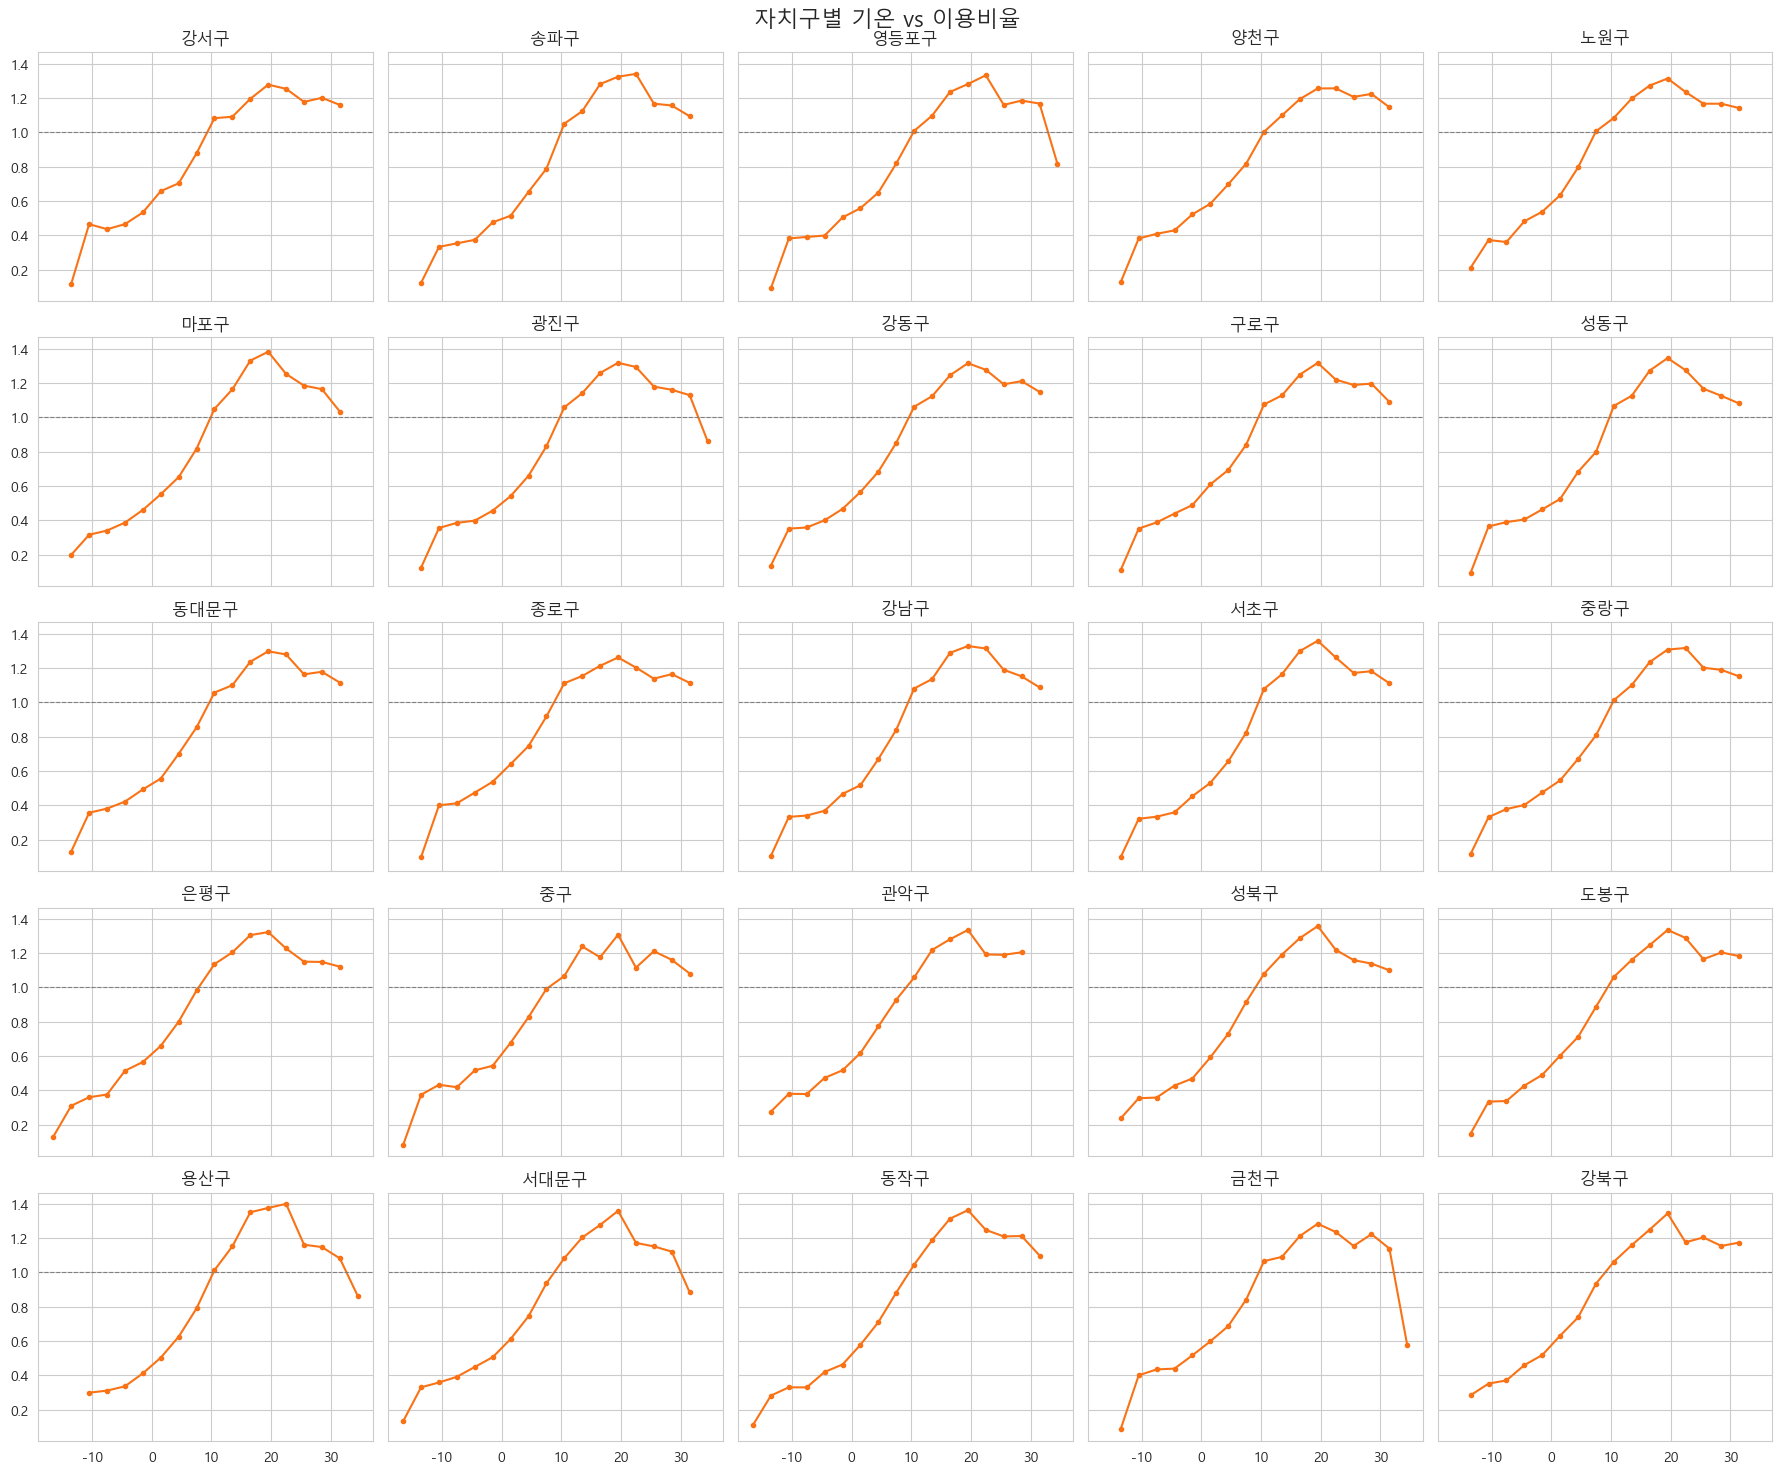

In [16]:
gu_order = df.groupby("자치구")["대여량"].sum().sort_values(ascending=False).index
curve = df.groupby(["자치구", "기온구간"], observed=True)["이용비율"].mean().reset_index()
curve["기온"] = curve["기온구간"].apply(lambda iv: iv.mid)

fig, axes = plt.subplots(5, 5, figsize=(18, 15), sharex=True, sharey=True)
for ax, gu in zip(axes.flat, gu_order):
    sub = curve[curve["자치구"] == gu]
    ax.plot(sub["기온"], sub["이용비율"], marker=".", color="#f97316")
    ax.axhline(1, color="gray", linestyle="--", linewidth=0.8)
    ax.set_title(gu)
fig.suptitle("자치구별 기온 vs 이용비율", fontsize=16)
plt.tight_layout()
plt.show()

### 5-6. 자치구별 날씨 민감도
나쁜 날씨일 때 평소보다 이용량이 몇 % 변했는지 구별로 비교합니다.
- 비: 5mm 이상 / 폭염: 최고기온 33℃ 이상 / 한파: 최저기온 -10℃ 이하 / 미세먼지: 나쁨 이상

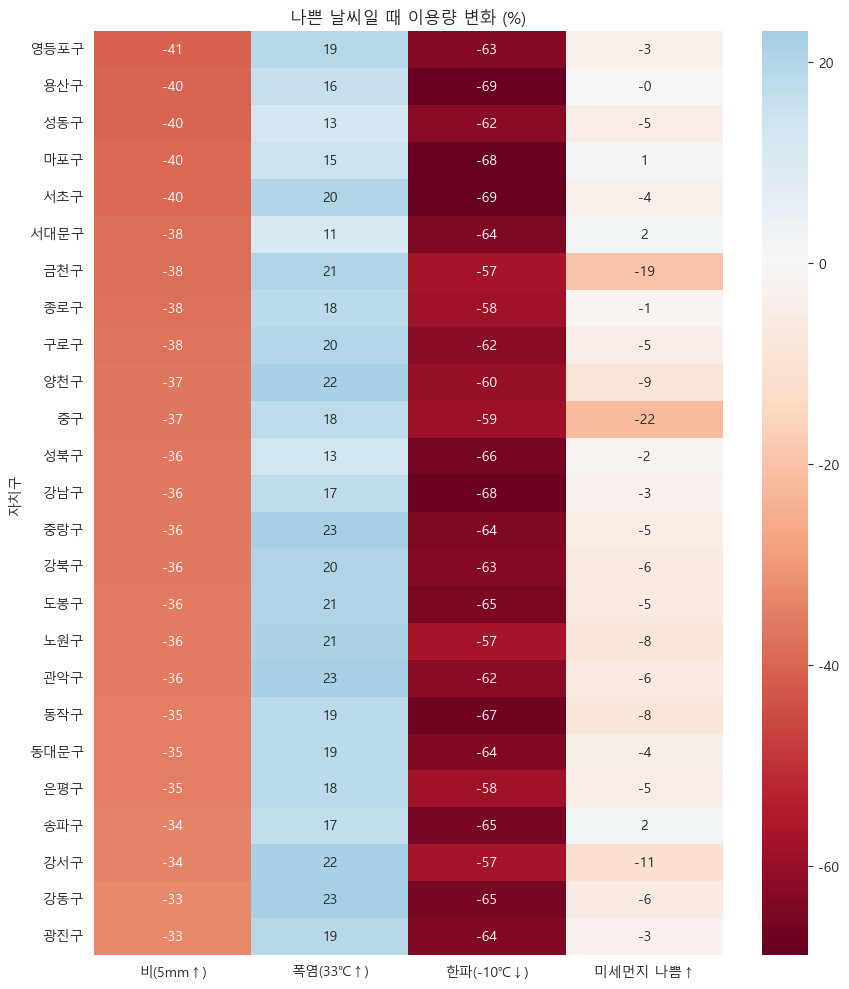

비(5mm↑): 191일
폭염(33℃↑): 113일
한파(-10℃↓): 41일
미세먼지 나쁨↑: 50일


In [17]:
conditions = {
    "비(5mm↑)": df["강수량"] >= 5,
    "폭염(33℃↑)": df["최고기온"] >= 33,
    "한파(-10℃↓)": df["최저기온"] <= -10,
    "미세먼지 나쁨↑": df["미세먼지"] > 80,
}
sens = pd.DataFrame({
    name: (df[cond].groupby("자치구")["이용비율"].mean() - 1) * 100
    for name, cond in conditions.items()
}).reindex(seoul_gu)
sens = sens.sort_values("비(5mm↑)")

plt.figure(figsize=(9, 10))
sns.heatmap(sens, annot=True, fmt=".0f", cmap="RdBu", center=0)
plt.title("나쁜 날씨일 때 이용량 변화 (%)")
plt.tight_layout()
plt.show()

for name, cond in conditions.items():
    print(f"{name}: {cond.sum() // len(seoul_gu)}일")

### 5-7. 요일 × 시간대 패턴

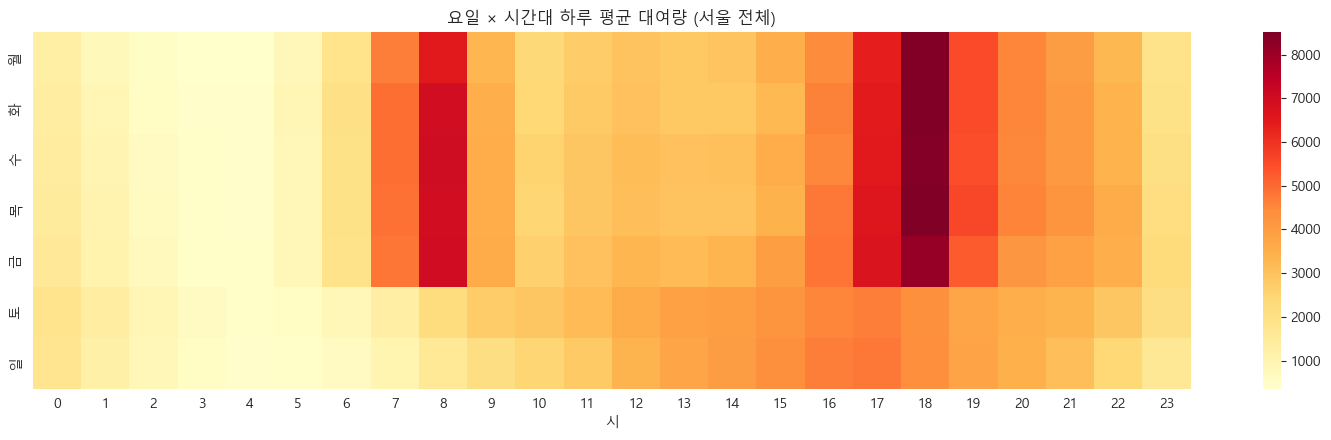

In [18]:
hourly["요일"] = hourly["일시"].dt.dayofweek
hourly["시간"] = hourly["일시"].dt.hour
n_days = hourly.groupby("요일")["날짜"].nunique()
week_hour = hourly.groupby(["요일", "시간"])["대여량"].sum().unstack()
week_hour = week_hour.div(n_days, axis=0)
week_hour.index = ["월", "화", "수", "목", "금", "토", "일"]

plt.figure(figsize=(15, 4.5))
sns.heatmap(week_hour, cmap="YlOrRd")
plt.title("요일 × 시간대 하루 평균 대여량 (서울 전체)")
plt.xlabel("시")
plt.tight_layout()
plt.show()

### 5-8. 계절별 시간대 패턴 (평일 vs 쉬는날)

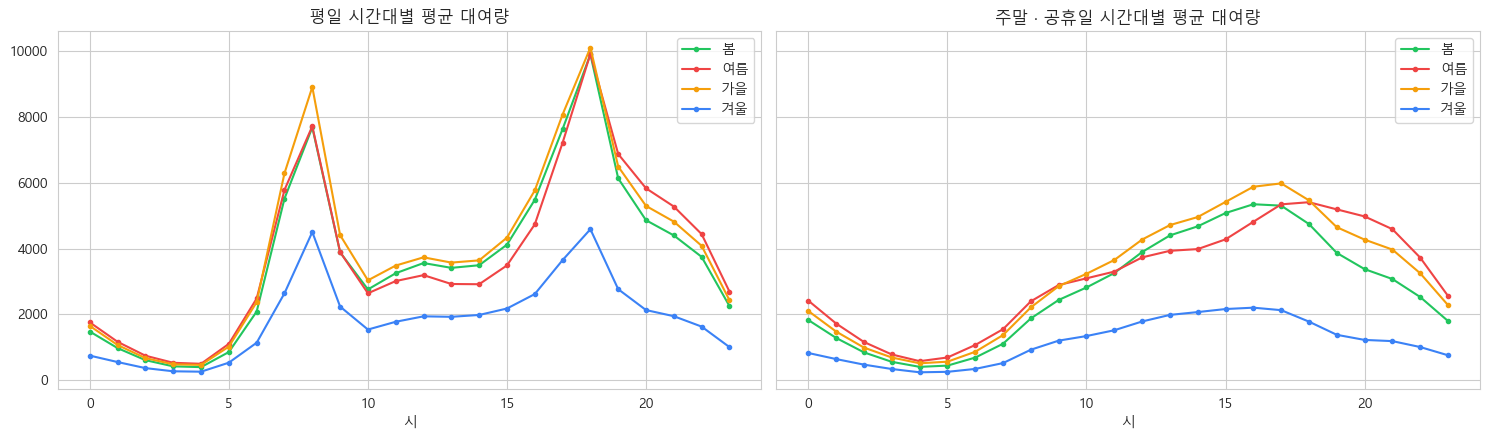

In [19]:
hourly["쉬는날"] = (hourly["요일"] >= 5) | hourly["날짜"].isin(HOLIDAYS)
hourly["계절"] = hourly["일시"].dt.month.map(SEASON)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), sharey=True)
for ax, off, title in [(axes[0], False, "평일"), (axes[1], True, "주말 · 공휴일")]:
    sub = hourly[hourly["쉬는날"] == off]
    days = sub.groupby("계절")["날짜"].nunique()
    pat = sub.groupby(["계절", "시간"])["대여량"].sum().unstack(0).div(days)
    for season, color in [("봄", "#22c55e"), ("여름", "#ef4444"), ("가을", "#f59e0b"), ("겨울", "#3b82f6")]:
        if season in pat.columns:
            ax.plot(pat.index, pat[season], marker=".", label=season, color=color)
    ax.set_title(f"{title} 시간대별 평균 대여량")
    ax.set_xlabel("시")
    ax.legend()
plt.tight_layout()
plt.show()

### 5-9. 변수 간 상관관계

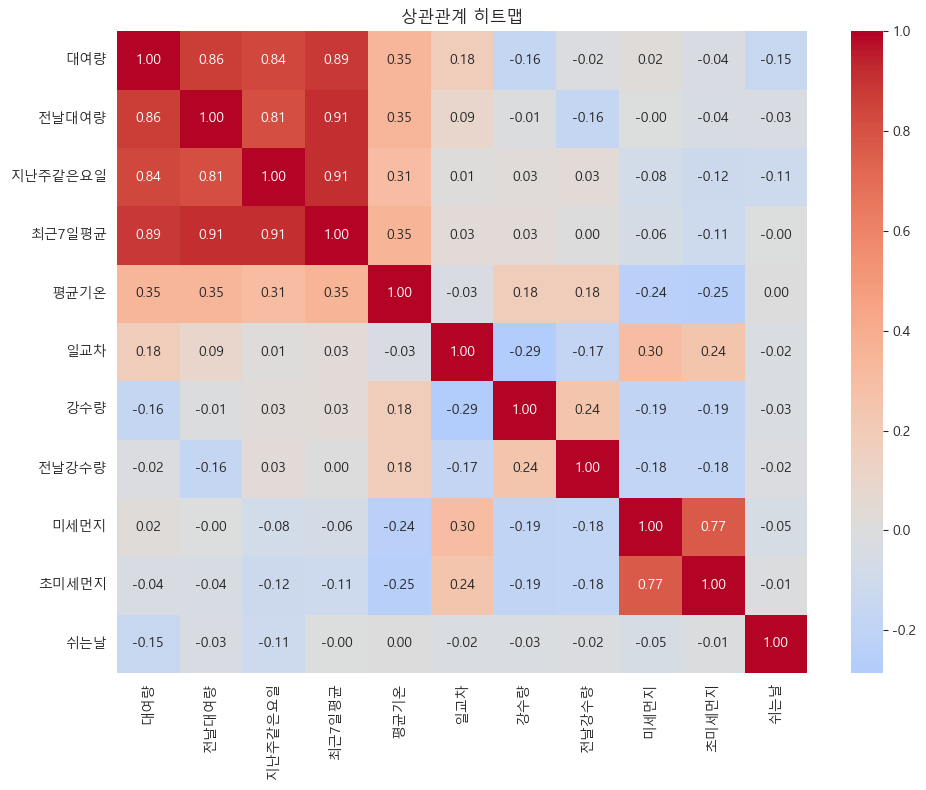

In [20]:
corr_cols = ["대여량", "전날대여량", "지난주같은요일", "최근7일평균",
             "평균기온", "일교차", "강수량", "전날강수량", "미세먼지", "초미세먼지", "쉬는날"]
plt.figure(figsize=(10, 8))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("상관관계 히트맵")
plt.tight_layout()
plt.show()

### 5-10. 다른 구에 반납하는 비율

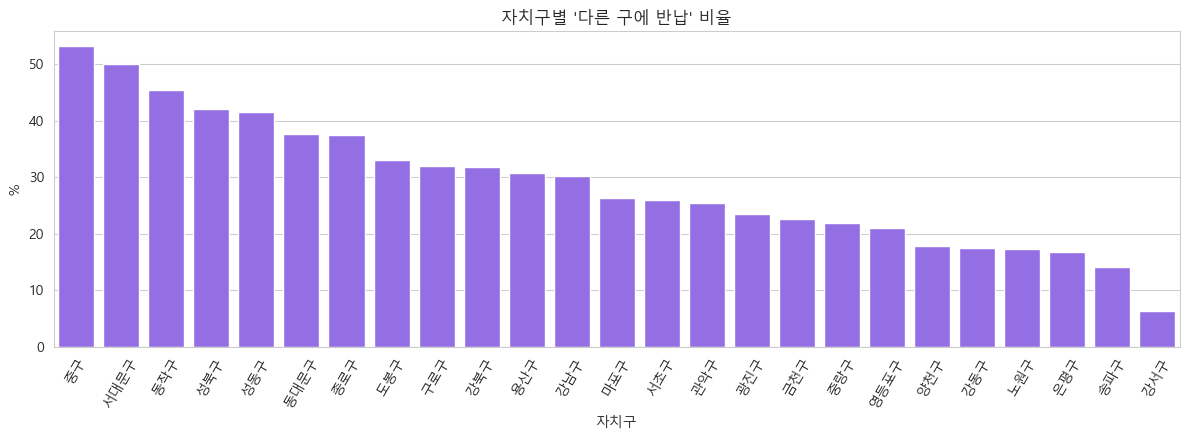

In [21]:
move = df.groupby("자치구")[["다른구반납", "대여량"]].sum()
move_rate = (move["다른구반납"] / move["대여량"] * 100).sort_values(ascending=False)

plt.figure(figsize=(12, 4.5))
sns.barplot(x=move_rate.index, y=move_rate.values, color="#8b5cf6")
plt.xticks(rotation=60)
plt.ylabel("%")
plt.title("자치구별 '다른 구에 반납' 비율")
plt.tight_layout()
plt.show()

### 5-11. 자치구 × 시간대 패턴 (평일)
각 구의 하루 이용량을 100%로 볼 때, 시간대별 비율입니다.
출퇴근 시간이 진한 구 = 통근형 / 오후 · 저녁이 진한 구 = 여가형

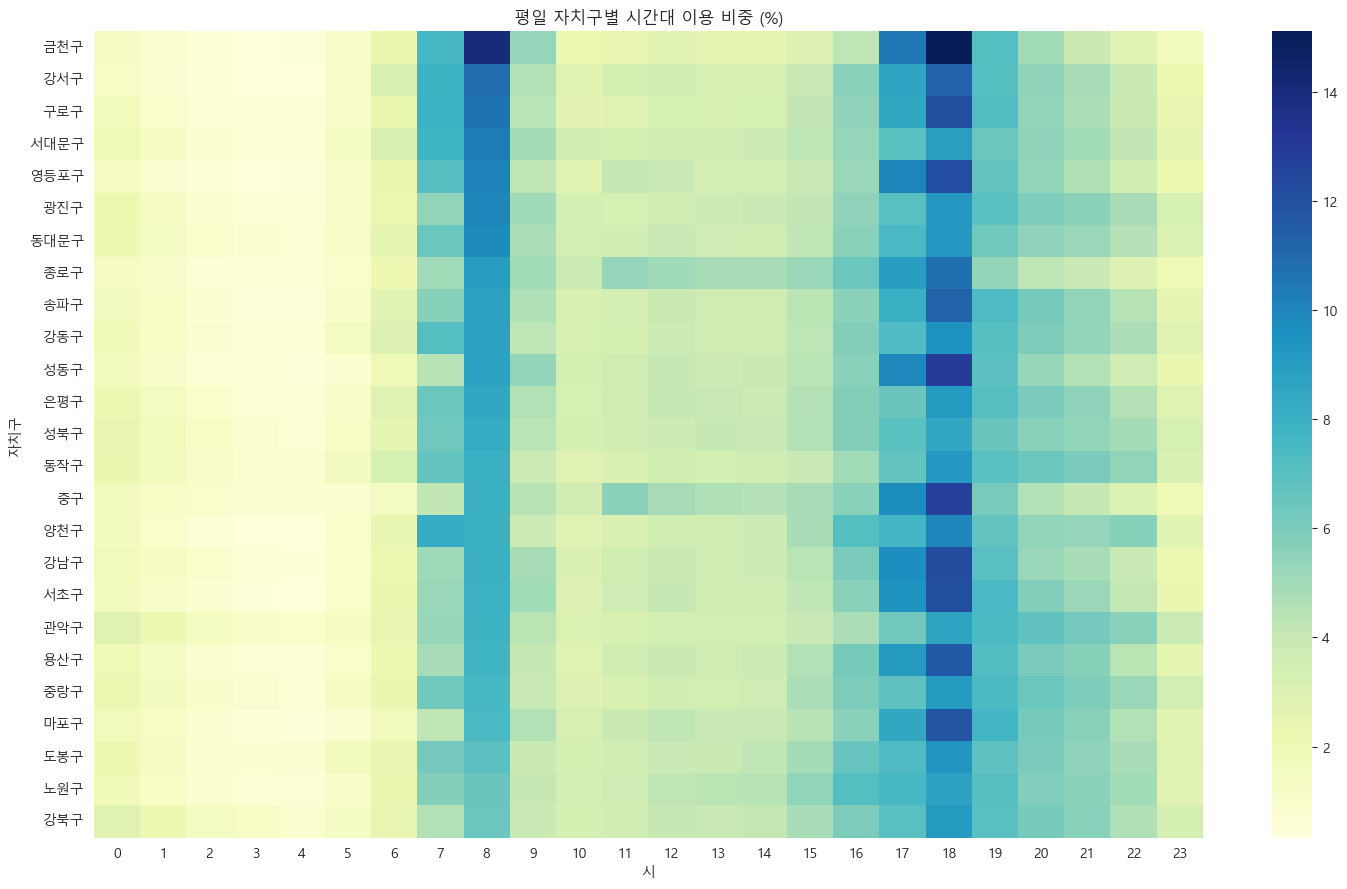

In [22]:
weekday = hourly[(~hourly["쉬는날"]) & (hourly["자치구"].isin(seoul_gu))]
gu_hour = weekday.groupby(["자치구", "시간"])["대여량"].sum().unstack()
gu_hour = gu_hour.div(gu_hour.sum(axis=1), axis=0) * 100
gu_hour = gu_hour.sort_values(8, ascending=False)   # 오전 8시 비중이 높은 구부터

plt.figure(figsize=(15, 9))
sns.heatmap(gu_hour, cmap="YlGnBu", annot=False)
plt.title("평일 자치구별 시간대 이용 비중 (%)")
plt.xlabel("시")
plt.tight_layout()
plt.show()

### 5-12. 비 오는 날 vs 안 오는 날 시간대 패턴 (평일)
비가 하루 종일 비슷하게 줄이는지, 특정 시간대만 줄이는지 확인합니다.

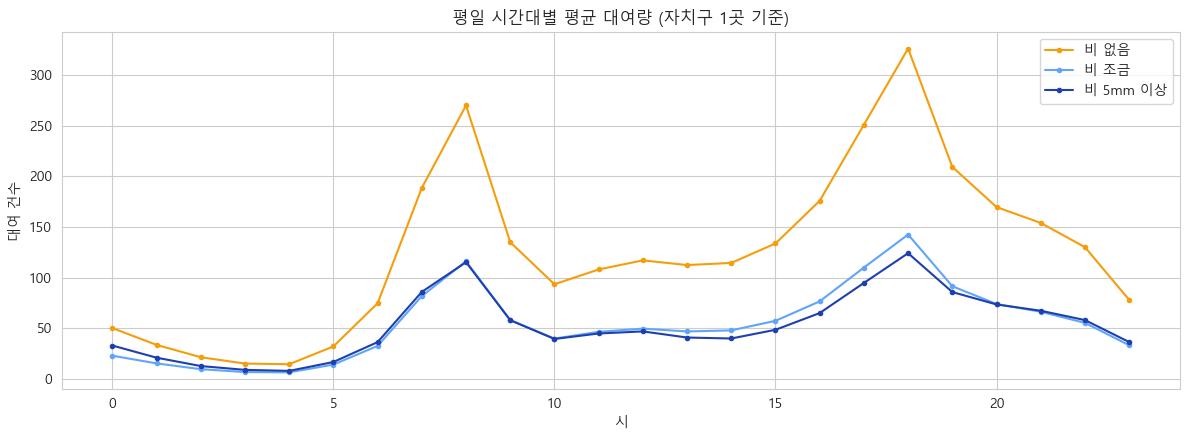

In [23]:
rain_day = df[["날짜", "자치구", "강수량"]]
wh = weekday.merge(rain_day, on=["날짜", "자치구"], how="left")
wh["날씨"] = np.where(wh["강수량"] >= 5, "비 5mm 이상", np.where(wh["강수량"] > 0, "비 조금", "비 없음"))

n_day = wh.groupby("날씨")["날짜"].nunique()
pat = wh.groupby(["날씨", "시간"])["대여량"].sum().unstack(0).div(n_day) / len(seoul_gu)

plt.figure(figsize=(12, 4.5))
for col, color in [("비 없음", "#f59e0b"), ("비 조금", "#60a5fa"), ("비 5mm 이상", "#1e40af")]:
    if col in pat.columns:
        plt.plot(pat.index, pat[col], marker=".", label=col, color=color)
plt.title("평일 시간대별 평균 대여량 (자치구 1곳 기준)")
plt.xlabel("시")
plt.ylabel("대여 건수")
plt.legend()
plt.tight_layout()
plt.show()

### 5-13. 분석 결과 요약

In [24]:
peak = t.idxmax()
print(f"- 가장 많이 타는 기온: {peak.left:.0f}~{peak.right:.0f}℃ (이용비율 {t.max():.2f})")
print(f"- 비 5mm 이상인 날: 평소 대비 평균 {sens['비(5mm↑)'].mean():+.0f}%")
print(f"- 비 영향이 가장 큰 구: {sens['비(5mm↑)'].idxmin()} ({sens['비(5mm↑)'].min():+.0f}%)")
print(f"- 비 영향이 가장 작은 구: {sens['비(5mm↑)'].idxmax()} ({sens['비(5mm↑)'].max():+.0f}%)")
print(f"- 출근시간(8시) 비중이 가장 높은 구: {gu_hour[8].idxmax()} ({gu_hour[8].max():.1f}%)")
yearly = df.groupby("연도")["대여량"].sum()
print(f"- 연도별 총 이용량(천 건): {(yearly / 1000).round(0).astype(int).to_dict()}")

- 가장 많이 타는 기온: 18~21℃ (이용비율 1.32)
- 비 5mm 이상인 날: 평소 대비 평균 -37%
- 비 영향이 가장 큰 구: 영등포구 (-41%)
- 비 영향이 가장 작은 구: 광진구 (-33%)
- 출근시간(8시) 비중이 가장 높은 구: 금천구 (14.1%)
- 연도별 총 이용량(천 건): {2022: 23866, 2023: 28688, 2024: 29615, 2025: 26030}


## 6. 시간 단위 모델링 데이터 만들기

한 행 = **(자치구, 날짜, 시간) 하나**, 정답 y = 그 시간의 대여량

**과거 대여량 변수는 "예측하는 시점에 이미 알 수 있는 값"만 넣습니다.**
예를 들어 내일 오후 6시를 예측할 때 "1시간 전 대여량"은 아직 모르는 값이라 쓸 수 없습니다.

| 변수 | 뜻 | 사용 가능한 경우 |
|---|---|---|
| 전날같은시간 | 24시간 전 대여량 | 하루 뒤까지 예측 |
| 최근7일같은시간평균 | 지난 7일 같은 시간 평균 | 하루 뒤까지 예측 |
| 전날총대여량 | 어제 그 구의 하루 대여량 | 하루 뒤까지 예측 |
| 지난주같은시간 | 168시간(7일) 전 대여량 | 일주일 뒤까지 예측 |

더 먼 미래(예: 한 달 뒤)를 예측할 거라면 과거 대여량 변수를 빼고 학습해야 합니다.

※ 과거 대여량을 계산하려면 7일치 기록이 필요해서, 데이터 시작 후 **첫 7일(2020-01-01~07)은 빠집니다.**

※ 여기서는 **2020년부터 전체**(`df_all`, `hourly_all`)로 만들고, 저장할 때 코로나 시기를 따로 나눕니다.

※ 날씨는 **일 단위** 데이터라 같은 날의 모든 시간에 같은 값이 들어갑니다.
기상청 시간별 자료가 생기면 이 부분만 바꾸면 됩니다.

In [25]:
# 1) 모든 시간 × 25개 구 조합 (기록 없는 시간 = 0건)
h = hourly_all.loc[hourly_all["자치구"].isin(seoul_gu), ["일시", "자치구", "대여량"]]
all_hours = pd.date_range(h["일시"].min().normalize(),
                          h["일시"].max().normalize() + pd.Timedelta(hours=23), freq="60min")
hgrid = pd.MultiIndex.from_product([all_hours, seoul_gu], names=["일시", "자치구"]).to_frame(index=False)
hdf = hgrid.merge(h, on=["일시", "자치구"], how="left")
hdf["대여량"] = hdf["대여량"].fillna(0).astype(int)
hdf["날짜"] = hdf["일시"].dt.normalize()
print("행 수:", len(hdf))

# 2) 날짜 · 날씨 · 휴일 변수 붙이기 (일별 데이터에서)
day_cols = ["날짜", "자치구", "연도", "월", "요일", "주말", "공휴일", "쉬는날",
            "평균기온", "최저기온", "최고기온", "일교차", "강수량", "비", "전날강수량",
            "미세먼지", "초미세먼지", "전날대여량"]
hdf = hdf.merge(df_all[day_cols], on=["날짜", "자치구"], how="left")
hdf = hdf.rename(columns={"전날대여량": "전날총대여량"})

# 3) 시간 변수
hdf["시간"] = hdf["일시"].dt.hour
hdf["출퇴근시간"] = ((hdf["쉬는날"] == 0) & hdf["시간"].isin([7, 8, 9, 17, 18, 19])).astype(int)

# 4) 과거 대여량 변수
hdf = hdf.sort_values(["자치구", "일시"]).reset_index(drop=True)
g = hdf.groupby("자치구")["대여량"]
hdf["전날같은시간"] = g.shift(24)
hdf["지난주같은시간"] = g.shift(168)

hdf = hdf.sort_values(["자치구", "시간", "일시"])   # 같은 구 · 같은 시간끼리 날짜순
hdf["최근7일같은시간평균"] = (
    hdf.groupby(["자치구", "시간"])["대여량"].transform(lambda s: s.shift(1).rolling(7).mean())
)
hdf = hdf.sort_values(["일시", "자치구"]).reset_index(drop=True)

# 5) 과거 값이 없는 앞쪽 7일 제거
before = len(hdf)
hdf = hdf.dropna(subset=["전날같은시간", "지난주같은시간", "최근7일같은시간평균", "전날총대여량"])
print(f"앞쪽 7일 제거: {before - len(hdf)}행")

# 6) 자치구 번호 (모델에 넣기 쉽게)
hdf["자치구코드"] = hdf["자치구"].map({gu: i for i, gu in enumerate(seoul_gu)})

hdf["최근7일같은시간평균"] = hdf["최근7일같은시간평균"].round(2)
for c in ["전날같은시간", "지난주같은시간", "전날총대여량"]:
    hdf[c] = hdf[c].astype(int)
print(hdf.shape)
print("결측치:", hdf.isna().sum().sum())
hdf.head()

행 수: 1315200
앞쪽 7일 제거: 4200행
(1311000, 26)
결측치: 0


,일시,자치구,대여량,날짜,연도,월,요일,주말,공휴일,쉬는날,...,전날강수량,미세먼지,초미세먼지,전날총대여량,시간,출퇴근시간,전날같은시간,지난주같은시간,최근7일같은시간평균,자치구코드
4200,2020-01-08,강남구,1,2020-01-08,2020,1,2,0,0,0,...,53.5,14.0,11.0,28,0,0,5,12,12.14,0
4201,2020-01-08,강동구,4,2020-01-08,2020,1,2,0,0,0,...,52.0,27.0,24.0,28,0,0,5,14,13.14,1
4202,2020-01-08,강북구,0,2020-01-08,2020,1,2,0,0,0,...,49.0,25.0,19.0,9,0,0,3,7,8.00,2
4203,2020-01-08,강서구,1,2020-01-08,2020,1,2,0,0,0,...,47.5,32.0,20.0,64,0,0,10,5,16.57,3
4204,2020-01-08,관악구,1,2020-01-08,2020,1,2,0,0,0,...,43.0,31.0,23.0,22,0,0,3,16,15.43,4


### 6-1. 만든 변수 확인
정답(대여량)과 과거 대여량 변수가 얼마나 비슷하게 움직이는지 봅니다.

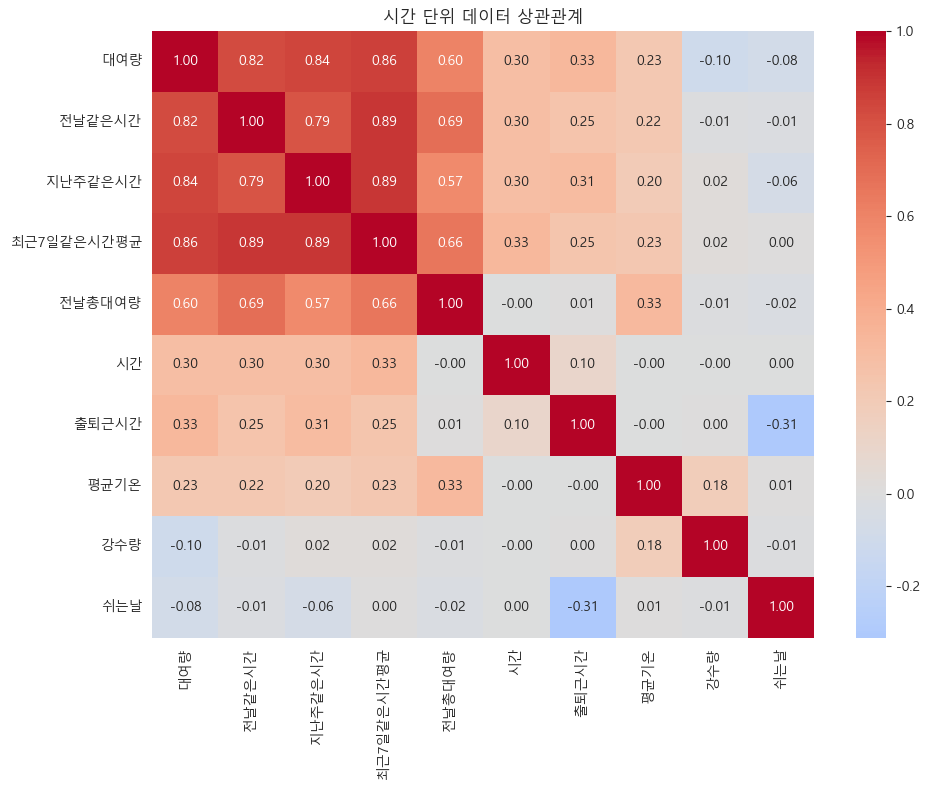

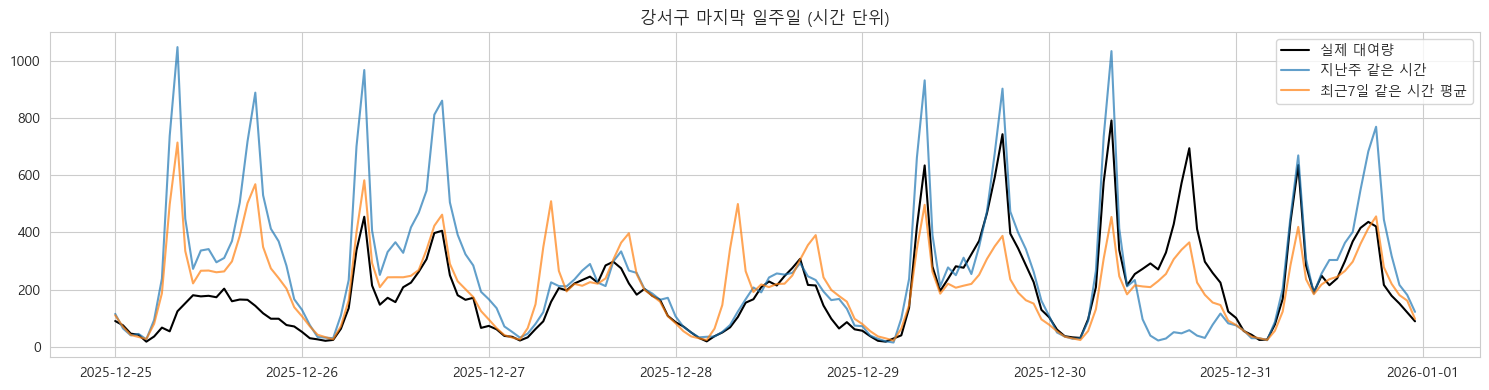

In [26]:
check_cols = ["대여량", "전날같은시간", "지난주같은시간", "최근7일같은시간평균", "전날총대여량",
              "시간", "출퇴근시간", "평균기온", "강수량", "쉬는날"]
plt.figure(figsize=(10, 8))
sns.heatmap(hdf[check_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("시간 단위 데이터 상관관계")
plt.tight_layout()
plt.show()

# 예시: 한 구의 일주일
sample_gu = gu_order[0]
week = hdf[(hdf["자치구"] == sample_gu)].tail(24 * 7)
plt.figure(figsize=(15, 4))
plt.plot(week["일시"], week["대여량"], label="실제 대여량", color="black")
plt.plot(week["일시"], week["지난주같은시간"], label="지난주 같은 시간", alpha=0.7)
plt.plot(week["일시"], week["최근7일같은시간평균"], label="최근7일 같은 시간 평균", alpha=0.7)
plt.title(f"{sample_gu} 마지막 일주일 (시간 단위)")
plt.legend()
plt.tight_layout()
plt.show()

## 7. 저장

팀원 모두가 **같은 데이터, 같은 기간**으로 모델을 비교할 수 있도록 나눠서 저장합니다.
시계열이므로 섞지 않고 기간으로 나눕니다.
- 학습(train): START_YEAR ~ 마지막 2년 전 (2022~2023)
- 검증(valid): 마지막에서 두 번째 해 → 모델 설정 고르기용
- 평가(test): 마지막 해 → 최종 성능 비교용 (마지막에 딱 한 번만 사용)
- 코로나(train_covid): READ_START_YEAR ~ START_YEAR 전 (2020~2021) → **비교용으로만** 사용

In [27]:
os.makedirs(OUT_DIR, exist_ok=True)   # OUT_DIR은 맨 위 설정에서 정함

TARGET = "대여량"
FEATURES = ["자치구코드", "연도", "월", "요일", "시간", "주말", "공휴일", "쉬는날", "출퇴근시간",
            "평균기온", "최저기온", "최고기온", "일교차", "강수량", "비", "전날강수량",
            "미세먼지", "초미세먼지",
            "전날같은시간", "지난주같은시간", "최근7일같은시간평균", "전날총대여량"]
INFO = ["일시", "날짜", "자치구"]   # 모델에는 안 넣지만 확인용으로 같이 저장

save_df = hdf[INFO + FEATURES + [TARGET]]

# 코로나 시기는 따로 저장 (train.csv 에는 섞지 않음)
covid_df = save_df[save_df["연도"] < START_YEAR]
save_df = save_df[save_df["연도"] >= START_YEAR]
covid_path = os.path.join(OUT_DIR, "train_covid.csv")
covid_df.to_csv(covid_path, index=False, encoding="utf-8-sig")
print(f"covid: {sorted(covid_df['연도'].unique().tolist())} → {len(covid_df):,}행 저장 ({covid_path})")

years = sorted(int(y) for y in save_df["연도"].unique())
if len(years) >= 3:
    split = {"train": years[:-2], "valid": [years[-2]], "test": [years[-1]]}
else:
    split = {"train": years[:-1], "test": [years[-1]]}

for name, ys in split.items():
    part = save_df[save_df["연도"].isin(ys)]
    path = os.path.join(OUT_DIR, f"{name}.csv")
    part.to_csv(path, index=False, encoding="utf-8-sig")
    print(f"{name:5s}: {ys} → {len(part):,}행 저장 ({path})")

# 변수 목록 저장 (팀원이 코드에서 그대로 불러 쓰기)
with open(os.path.join(OUT_DIR, "features.txt"), "w", encoding="utf-8") as fp:
    fp.write("\n".join(FEATURES))
print("변수 목록 저장: features.txt")

# 공휴일 목록 (미래 예측할 때 사용)
with open(os.path.join(OUT_DIR, "holidays.txt"), "w", encoding="utf-8") as fp:
    fp.write("\n".join(HOLIDAYS.strftime("%Y-%m-%d")))
print("공휴일 목록 저장: holidays.txt")

# 대여소별 데이터 (웹 대여소별 예측용)
station_save = station[station["자치구"].isin(seoul_gu)]
station_save.to_csv(os.path.join(OUT_DIR, "대여소_월별시간별.csv"), index=False, encoding="utf-8-sig")
print(f"대여소 데이터 저장: {len(station_save):,}행 ({station_save['연월'].min()} ~ {station_save['연월'].max()})")

# 일별 분석 데이터도 같이 저장
day_save = [c for c in df.columns if c not in ["기온구간", "강수구간", "미세먼지등급"]]
df[day_save].to_csv(os.path.join(OUT_DIR, "일별_분석데이터.csv"), index=False, encoding="utf-8-sig")
print("일별 분석 데이터 저장 완료")

covid: [2020, 2021] → 434,400행 저장 (./model_data_2022\train_covid.csv)
train: [2022, 2023] → 438,000행 저장 (./model_data_2022\train.csv)
valid: [2024] → 219,600행 저장 (./model_data_2022\valid.csv)
test : [2025] → 219,000행 저장 (./model_data_2022\test.csv)
변수 목록 저장: features.txt
공휴일 목록 저장: holidays.txt
대여소 데이터 저장: 2,808,423행 (2024-01 ~ 2025-12)
일별 분석 데이터 저장 완료


### 팀원용: 저장한 데이터 불러오는 방법
```python
import pandas as pd

train = pd.read_csv("model_data_2022/train.csv", parse_dates=["일시"])
valid = pd.read_csv("model_data_2022/valid.csv", parse_dates=["일시"])
features = open("model_data_2022/features.txt", encoding="utf-8").read().splitlines()

X_train, y_train = train[features], train["대여량"]
X_valid, y_valid = valid[features], valid["대여량"]
```
- **기준선**: `valid["지난주같은시간"]`을 그대로 예측값으로 써서 나온 오차보다 낮아야 의미 있는 모델입니다.
- 코로나 시기를 포함해서 학습해 보려면 `train_covid.csv`를 `train`에 이어 붙이면 됩니다.
- 먼 미래를 예측하는 모델이라면 `features`에서 과거 대여량 변수 4개를 빼고 학습하세요.